In [ ]:
import pandas as pd
import os
import sys
import numpy as np
sys.path.append(r'D:\code\github\strainOptimizer')
from strainOptimizer.analysis.dataset import calculate_exp_consistency,load_experiment_targets

# set work dir
os.chdir(r'D:\code\github\strainOptimizer')

In [87]:
slim_result_df=pd.DataFrame(columns=['model_type','simulation_method','product_name','consistency','precision','predict_num','average_distance','connectivity_score'])
total_resulat_dict={}
for file in os.listdir(r'analysis_code\results\moma_mopa_pfba'):
    if (file.endswith('.xlsx') or file.endswith('.csv')) and 'etfl' not in file:
        if 'gluc_10' not in file and 'ppfba' not in file and 'GAN' not in file:
            continue
        if 'gluc_1_' in file and 'GAN' in file:
            continue
        # if 'gluc_10' in file:
        #     continue
        model_type=file.split('_')[0]
        product_name=file.split('_')[1]
        simulation_method=file.split('_')[4]
        
        # load predicted result
        if file.endswith('.xlsx'):
            df=pd.read_excel(f'analysis_code/results/moma_mopa_pfba/{file}',sheet_name='geneTable',index_col=0)
        elif file.endswith('.csv'):
            # df=pd.read_csv(f'analysis_code/results/moma_mopa_pfba/{file}',index_col=0)
            continue
        df=df.replace([np.inf, -np.inf], np.nan)
         # load experimental result
        if product_name=='free fatty acids':
            product_name='ffa'
        exp_data=load_experiment_targets(product_name)
        # remove nan in index
        exp_data=exp_data[exp_data.index.notna()]

        # check if total result dict have simulation_method item
        if 'GAN' in model_type:
            simulation_method_mod=simulation_method+'_'+model_type
        else:
            simulation_method_mod=simulation_method
        if simulation_method_mod not in total_resulat_dict:
            total_resulat_dict[simulation_method_mod]={'prediction':[],
                                                  'experiment':[]}
        exp_list=[product_name+'_'+gene for gene in exp_data.index]
        pred_list=[product_name+'_'+gene for gene in df.index]
        total_resulat_dict[simulation_method_mod]['prediction'].extend(pred_list)
        total_resulat_dict[simulation_method_mod]['experiment'].extend(exp_list)
        
        # calculate experiment consistency
        eval_result=calculate_exp_consistency(df,exp_data,show=False)

        # calculate exp consistency and accuracy
        consistency_score=eval_result['overall']['consistency']
        precision_score=eval_result['overall']['precision']
        predict_num=eval_result['overall']['predict_num']
        try:
            average_distance=df['distance'].mean(skipna=True)
            connectivity_score=df['count'].median(skipna=True)
        except:
            average_distance=0
            connectivity_score=0
        # slim_result_dict[model_type][product_name]={'consistency':consistency_score,'accuracy':accuracy_score}
        # add new row to df
        new_row = pd.DataFrame({'model_type':[model_type],
                                'product_name':[product_name],
                                'simulation_method':[simulation_method],
                                'consistency':[consistency_score],
                                'precision':[precision_score],
                                'predict_num':[predict_num],
                                'average_distance':[average_distance],
                                'connectivity_score':[connectivity_score]})
        slim_result_df = pd.concat([slim_result_df, new_row], ignore_index=True)

# # add ppfba result
# for file in os.listdir(r'analysis_code\results\ecGEM_vs_efl'):
#     if file.endswith('.xlsx') and 'etfl' not in file:
#         # if 'gluc_10' not in file:
#         #     continue
#         model_type=file.split('_')[0]
#         product_name=file.split('_')[1]
#         simulation_method='ppfba'

#         # load predicted result
#         df=pd.read_excel(f'analysis_code/results/ecGEM_vs_efl/{file}',sheet_name='geneTable',index_col=0)
#         df=df.replace([np.inf, -np.inf], np.nan)

#          # load experimental result
#         if product_name=='free fatty acids':
#             product_name='ffa'
#         exp_data=load_experiment_targets(product_name)
#         exp_data=exp_data[exp_data.index.notna()]

#         # check if total result dict have simulation_method item
#         if 'GAN' in model_type:
#             simulation_method_mod=simulation_method+'_'+model_type
#         else:
#             simulation_method_mod=simulation_method
#         if simulation_method_mod not in total_resulat_dict:
#             total_resulat_dict[simulation_method_mod]={'prediction':[],
#                                                   'experiment':[]}
#         exp_list=[product_name+'_'+gene for gene in exp_data.index]
#         pred_list=[product_name+'_'+gene for gene in df.index]
#         total_resulat_dict[simulation_method_mod]['prediction'].extend(pred_list)
#         total_resulat_dict[simulation_method_mod]['experiment'].extend(exp_list)

#         # calculate experiment consistency
#         eval_result=calculate_exp_consistency(df,exp_data,show=False)


#         # calculate exp consistency and accuracy
#         consistency_score=eval_result['overall']['consistency']
#         precision_score=eval_result['overall']['precision']
#         predict_num=eval_result['overall']['predict_num']
#         average_distance=df['distance'].mean(skipna=True)
#         connectivity_score=df['count'].median(skipna=True)
#         # slim_result_dict[model_type][product_name]={'consistency':consistency_score,'accuracy':accuracy_score}
#         # add new row to df
#         new_row = pd.DataFrame({'model_type':[model_type],
#                                 'product_name':[product_name],
#                                 'simulation_method':[simulation_method],
#                                 'consistency':[consistency_score],
#                                 'precision':[precision_score],
#                                 'predict_num':[predict_num],
#                                 'average_distance':[average_distance],
#                                 'connectivity_score':[connectivity_score]})
#         slim_result_df = pd.concat([slim_result_df, new_row], ignore_index=True)

slim_result_df=slim_result_df[slim_result_df['model_type']!='GAN']
# if model_type = GANall, add GAN_ to the simulation_method
slim_result_df['simulation_method']=slim_result_df.index.map(lambda x: slim_result_df.loc[x,'simulation_method']+'_GAN' if slim_result_df.loc[x,'model_type']=='GANall' else slim_result_df.loc[x,'simulation_method'])

keep_methods=['moma','mopa','mopa_GAN','pfba','ppfba','ppfba_GAN']
slim_result_df=slim_result_df[slim_result_df['simulation_method'].isin(keep_methods)]
slim_result_df

C:\Users\wangh\AppData\Local\Temp\ipykernel_22016\3013568886.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  slim_result_df = pd.concat([slim_result_df, new_row], ignore_index=True)


,model_type,simulation_method,product_name,consistency,precision,predict_num,average_distance,connectivity_score
0,ecGEM,moma,2-phenylethanol,0.750000,0.204545,44,6.484688,9.5
1,ecGEM,mopa,2-phenylethanol,0.750000,0.300000,30,6.277108,18.0
2,ecGEM,pfba,2-phenylethanol,0.666667,0.153846,52,6.254846,17.0
3,ecGEM,ppfba,2-phenylethanol,0.666667,0.228571,35,0.000000,0.0
4,ecGEM,moma,ffa,0.222222,0.056338,71,6.867200,5.0
5,ecGEM,mopa,ffa,0.222222,0.067797,59,5.883470,8.0
6,ecGEM,pfba,ffa,0.166667,0.111111,27,6.298942,13.0
7,ecGEM,ppfba,ffa,0.277778,0.078125,64,0.000000,0.0
8,ecGEM,moma,heme,0.368421,0.285714,49,6.775253,5.0
9,ecGEM,mopa,heme,0.368421,0.304348,46,6.937868,4.0


In [92]:
# # save result
slim_result_df.to_csv(r'analysis_code\results/moma_vs_mopa_vs_pfba_vs_ppfba.csv',index=False)

C:\Users\wangh\AppData\Local\Temp\ipykernel_22016\4281530111.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=45)


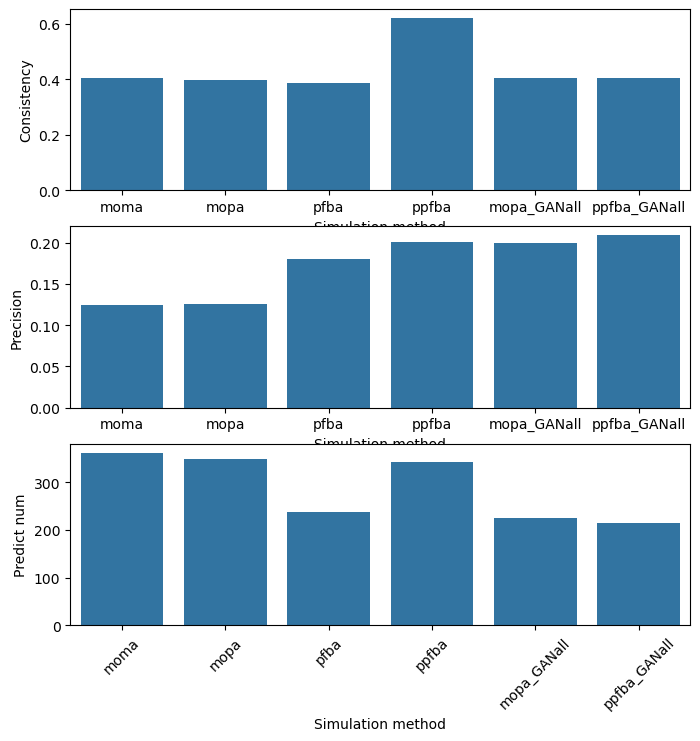

In [88]:
# calculate  total performance
df_total_result=pd.DataFrame(columns=['consistency','precision','predict_num'])
for key,value in total_resulat_dict.items():
    prediction=set(value['prediction'])
    experiment=set(value['experiment'])
    # calculate consistency
    consistency=len(prediction&experiment)/len(experiment)
    # calculate precision
    precision=len(prediction&experiment)/len(prediction)
    # calculate predict num
    predict_num=len(prediction)
    # add to df
    df_total_result.loc[key]=[consistency,precision,predict_num]
to_remove=['pfba_GANall','moma_GANall','mopa_GAN','ppfba_GAN']
df_total_result=df_total_result[~df_total_result.index.isin(to_remove)]

# plot bar plot
import matplotlib.pyplot as plt
import seaborn as sns
fig,ax=plt.subplots(3,1,figsize=(8,8))
# plot consistency
sns.barplot(x=df_total_result.index,y='consistency',data=df_total_result,ax=ax[0])
ax[0].set_xlabel('Simulation method')
ax[0].set_ylabel('Consistency')

# plot precision
sns.barplot(x=df_total_result.index,y='precision',data=df_total_result,ax=ax[1])
ax[1].set_xlabel('Simulation method')
ax[1].set_ylabel('Precision')

# plot predict num
sns.barplot(x=df_total_result.index,y='predict_num',data=df_total_result,ax=ax[2])
ax[2].set_xlabel('Simulation method')
ax[2].set_ylabel('Predict num')
ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=45)

plt.show()

In [91]:
# save result
df_total_result.to_csv(r'analysis_code\results\moma_vs_mopa_vs_pfba_vs_ppfba_allproducts_performance.csv')

C:\Users\wangh\AppData\Local\Temp\ipykernel_22016\2347089323.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(rotation=0,labels=x_ticks_list)


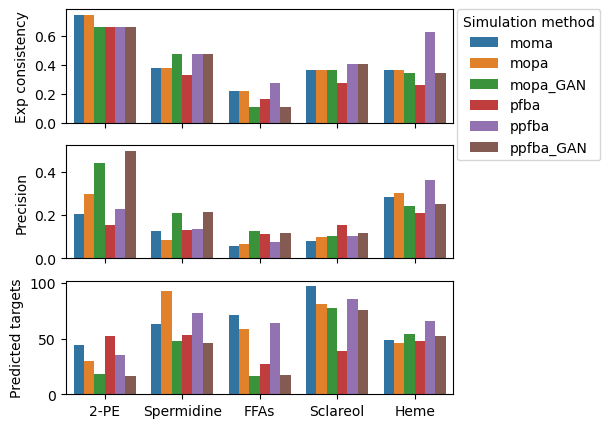

In [89]:
# plot the barplots for consistency, accuracy and predict num 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# slim_result_df=pd.read_csv(r'analysis_code/results/slim_result_df.csv')
# plot the barplots for consistency, accuracy and predict num and hue by simulation method
fig,axs=plt.subplots(3,1,figsize=(5,5))

product_name_order ={'2-phenylethanol':0,'spermidine':1,'ffa':2,'sclareol':3,'heme':4}
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='simulation_method',data=slim_result_df,ax=axs[0],order=product_name_order.keys(),hue_order=keep_methods)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Exp consistency')
# set legend outside 
axs[0].legend(title='Simulation method',bbox_to_anchor=(1.01, 1), borderaxespad=0.)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='simulation_method',data=slim_result_df,ax=axs[1],legend=False,order=product_name_order.keys(),hue_order=keep_methods)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision')


# plot experiment predict num
sns.barplot(x='product_name',y='predict_num',hue='simulation_method',data=slim_result_df,ax=axs[2],legend=False,order=product_name_order.keys(),hue_order=keep_methods)
# set x, y ticks
# set x ticks
x_ticks_dict={'2-phenylethanol':'2-PE',
              'heme':'Heme',
              'ffa':'FFAs',
              'sclareol':'Sclareol',
              'spermidine':'Spermidine'}
x_ticks_list=[x_ticks_dict[i] for i in product_name_order.keys()]
axs[2].set_xticklabels(rotation=0,labels=x_ticks_list)
axs[2].set_xlabel('')
axs[2].set_ylabel('Predicted targets')
plt.show()

C:\Users\wangh\AppData\Local\Temp\ipykernel_22016\106590202.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='simulation_method',y='consistency',data=slim_result_df,ax=axs[0],order=keep_methods,palette=color_dict,errorbar=None)
C:\Users\wangh\AppData\Local\Temp\ipykernel_22016\106590202.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='simulation_method',y='precision',data=slim_result_df,ax=axs[1],legend=False,order=keep_methods,palette=color_dict,errorbar=None)
C:\Users\wangh\AppData\Local\Temp\ipykernel_22016\106590202.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels

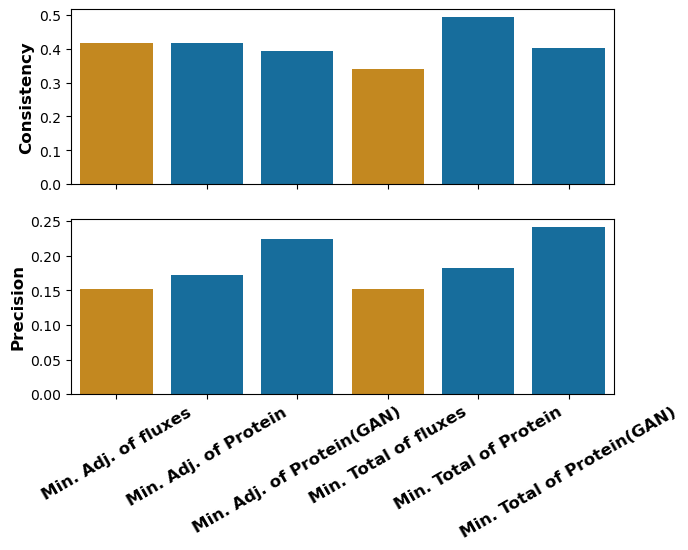

In [90]:
# plot the box plot for different simulation method
palette=sns.color_palette("colorblind")
fig,axs=plt.subplots(2,1,figsize=(7,5))

x_ticks_dict={'mopa':'Min. Adj. of Protein',
              'moma':'Min. Adj. of fluxes',
              'ppfba':'Min. Total of Protein',
              'pfba':'Min. Total of fluxes',
              'mopa_GAN':'Min. Adj. of Protein(GAN)',
              'ppfba_GAN':'Min. Total of Protein(GAN)',
              'moma_GAN':'Min. Adj. of fluxes(GAN)',
              'pfba_GAN':'Min. Total of fluxes(GAN)',}

keep_methods=['moma','mopa','mopa_GAN','pfba','ppfba','ppfba_GAN']
x_ticks_list=[x_ticks_dict[i] for i in keep_methods]

color_dict={}
for i,item in x_ticks_dict.items():
    if 'Protein' in item:
        color_dict[i]=palette[0]
    else:
        color_dict[i]=palette[1]

# # calculate the p value between moma vs mopa, and pfba vs ppfba
# import scipy.stats as stats
# moma_consistency=slim_result_df[slim_result_df['simulation_method']=='moma']['consistency']
# mopa_consistency=slim_result_df[slim_result_df['simulation_method']=='mopa']['consistency']
# pfba_consistency=slim_result_df[slim_result_df['simulation_method']=='pfba']['consistency']
# ppfba_consistency=slim_result_df[slim_result_df['simulation_method']=='ppfba']['consistency']
# moma_precision=slim_result_df[slim_result_df['simulation_method']=='moma']['precision']
# mopa_precision=slim_result_df[slim_result_df['simulation_method']=='mopa']['precision']
# pfba_precision=slim_result_df[slim_result_df['simulation_method']=='pfba']['precision']
# ppfba_precision=slim_result_df[slim_result_df['simulation_method']=='ppfba']['precision']

# # calculate the p value with paied values
# p_value_moma_mopa_consistency=stats.ttest_rel(moma_consistency,mopa_consistency).pvalue
# p_value_pfba_ppfba_consistency=stats.ttest_rel(pfba_consistency,ppfba_consistency).pvalue
# p_value_moma_mopa_precision=stats.ttest_rel(moma_precision,mopa_precision).pvalue
# p_value_pfba_ppfba_precision=stats.ttest_rel(pfba_precision,ppfba_precision).pvalue
# print(f'p value between moma vs mopa: {p_value_moma_mopa_consistency}, p value between pfba vs ppfba: {p_value_pfba_ppfba_consistency}')
# print(f'p value between moma vs mopa: {p_value_moma_mopa_precision}, p value between pfba vs ppfba: {p_value_pfba_ppfba_precision}')
# plot Exp consistency
sns.barplot(x='simulation_method',y='consistency',data=slim_result_df,ax=axs[0],order=keep_methods,palette=color_dict,errorbar=None)
# plot the point
# sns.stripplot(x='simulation_method',y='consistency',data=slim_result_df,ax=axs[0],order=keep_methods,color='red',size=5,alpha=1)
# axs[0].set_xticklabels(x_ticks_list,rotation=45,fontweight='bold',fontsize=12)
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Consistency',fontweight='bold',fontsize=12)
# set y lim
# axs[0].set_ylim(0.2,0.5)

sns.barplot(x='simulation_method',y='precision',data=slim_result_df,ax=axs[1],legend=False,order=keep_methods,palette=color_dict,errorbar=None)
# plot the point
# sns.stripplot(x='simulation_method',y='accuracy',data=slim_result_df,ax=axs[1],legend=False,order=keep_methods,color='red',size=5,alpha=1)
axs[1].set_xticklabels(x_ticks_list,rotation=30,fontweight='bold',fontsize=12)
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=12)
# axs[1].set_ylim(0.1,0.2)

# sns.barplot(x='simulation_method',y='average_distance',data=slim_result_df,ax=axs[2],legend=False,order=keep_methods,palette=color_dict,errorbar=None)

# sns.barplot(x='simulation_method',y='connectivity_score',data=slim_result_df,ax=axs[3],legend=False,order=keep_methods,palette=color_dict,errorbar=None)

# save it
# fig.savefig('pFBA_ppFBA_moma_mopa_evaluation.png',dpi=300,bbox_inches='tight')
plt.show()

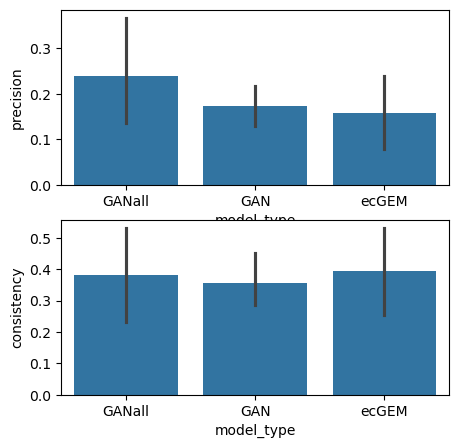

In [40]:
df_select=slim_result_df[slim_result_df['simulation_method']=='ppfba']
# plot 
fig,ax=plt.subplots(2,1,figsize=(5,5))
sns.barplot(x='model_type',y='precision',data=df_select,ax=ax[0])
sns.barplot(x='model_type',y='consistency',data=df_select,ax=ax[1])
plt.show()

In [234]:
slim_result_df[slim_result_df['simulation_method']=='mopa']

,model_type,simulation_method,product_name,consistency,precision,predict_num,average_distance,connectivity_score
1,ecGEM,mopa,2-phenylethanol,0.692308,0.300000,30,6.277108,18.0
4,ecGEM,mopa,ffa,0.222222,0.067797,59,5.883470,8.0
7,ecGEM,mopa,heme,0.368421,0.304348,46,6.937868,4.0
10,ecGEM,mopa,sclareol,0.363636,0.098765,81,7.291364,8.0
13,ecGEM,mopa,spermidine,0.380952,0.086022,93,6.301811,10.0
15,etfl,mopa,2-phenylethanol,0.615385,0.100000,80,6.676408,20.5


## check the protein allocation and fluxes distribution difference between growth status and production status

In [16]:
def min_max_normalize(data, feature_range=(0, 1)):
    """
    Min-Max 归一化函数，支持一维和二维数据
    :param data: 输入数据 (list, numpy array, pandas Series, pandas DataFrame)
    :param feature_range: 目标范围 (min, max)，默认 (0,1)
    :return: 归一化后的 numpy array 或 DataFrame
    """
    a, b = feature_range
    
    # 转换输入
    if isinstance(data, pd.DataFrame):
        return data.apply(lambda col: _normalize_array(col.values, a, b), axis=0)
    elif isinstance(data, pd.Series):
        return pd.Series(_normalize_array(data.values, a, b), index=data.index)
    else:
        arr = np.array(data, dtype=float)
        if arr.ndim == 1:
            return _normalize_array(arr, a, b)
        elif arr.ndim == 2:
            return np.apply_along_axis(_normalize_array, 0, arr, a, b)
        else:
            raise ValueError("仅支持一维或二维数据")

def _normalize_array(arr, a, b):
    """对一维数组进行归一化"""
    min_val, max_val = np.min(arr), np.max(arr)
    if min_val == max_val:  # 避免除零
        return np.full_like(arr, (a+b)/2, dtype=float)
    return a + (arr - min_val) * (b - a) / (max_val - min_val)

# calculate the Manhattan distance
def manhattan_distance(x, y):
    x, y = np.array(x), np.array(y)
    return np.sum(np.abs(x - y))

In [27]:
import pandas as pd
import scipy.stats as stats
dfs = pd.read_excel(r'analysis_code\results\wt_vs_mutant_protein_flux.xlsx', sheet_name=None, index_col=0)

df_flux_all=pd.DataFrame(columns=['WT','mutant'])
df_protein_all=pd.DataFrame(columns=['WT','mutant'])
# calculate protein allocation difference by spearman correlation
products_result={}
for key,df in dfs.items():
    type=key.split('_')[0]

    if type=='protein':
        df_protein_all=pd.concat([df_protein_all,df],axis=0,ignore_index=True)
    elif type=='flux':
        df_flux_all=pd.concat([df_flux_all,df],axis=0,ignore_index=True)
    # if type=='protein':
    product=key.split('_')[1]
    # 初始化字典
    if product not in products_result:
        products_result[product] = {}
    # remove rows with all 0 value
    df=df[df.sum(axis=1)!=0]
    # calculate correlation
    corr,p=stats.spearmanr(df['WT'],df['mutant'])
    if p>0.05:
        corr=0
        print(f'{product} {type} p-value is {p}, correlation is {corr}')
    products_result[product][type]=corr

    # calculate the distance
    df_scaled=min_max_normalize(df)
    df_scaled_WT=df_scaled['WT']
    df_scaled_mutant=df_scaled['mutant']
    distance=manhattan_distance(df_scaled_WT,df_scaled_mutant)
    # print(f'{product} {type} distance: {distance}')
    products_result[product][type+'_distance']=distance

products_result

# convert to dataframe
products_result_df=pd.DataFrame(products_result)
products_result_df


C:\Users\wangh\AppData\Local\Temp\ipykernel_39304\2273006517.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_protein_all=pd.concat([df_protein_all,df],axis=0,ignore_index=True)
C:\Users\wangh\AppData\Local\Temp\ipykernel_39304\2273006517.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_flux_all=pd.concat([df_flux_all,df],axis=0,ignore_index=True)


,2-phenylethanol,heme,spermidine,sclareol,fatty
protein,0.465788,-0.121344,0.181627,0.307526,0.280872
protein_distance,9.095774,10.729563,10.331232,9.250087,9.133646
flux,0.340709,0.156641,0.243416,0.314006,0.241815
flux_distance,17.657829,16.137855,15.394572,14.393024,15.007197


In [8]:
# save result
products_result_df.to_csv(r'analysis_code\results\wt_vs_mutant_protein_flux_distance.csv')

C:\Users\wangh\AppData\Local\Temp\ipykernel_39304\632133348.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Protein level','Flux level'],fontweight='bold',fontsize=12)


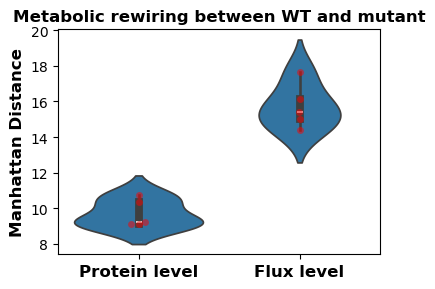

In [28]:
# plot the boxplot the compare the distance 
df_1d=pd.DataFrame({'distance':products_result_df.loc['protein_distance',:].values.tolist()+products_result_df.loc['flux_distance',:].values.tolist(),'type':['protein']*len(products_result_df.loc['protein_distance',:])+['flux']*len(products_result_df.loc['flux_distance',:])})

# sns.boxplot(x='type',y='distance',data=df_1d,showfliers=False,)
fig,ax=plt.subplots(figsize=(4,3))
sns.swarmplot(x='type',y='distance',data=df_1d,color='red',alpha=0.5,ax=ax)
sns.violinplot(x='type',y='distance',data=df_1d,ax=ax)
ax.set_xticklabels(['Protein level','Flux level'],fontweight='bold',fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Manhattan Distance',fontweight='bold',fontsize=12)
ax.set_title('Metabolic rewiring between WT and mutant',fontweight='bold',fontsize=12)
# ax.set_ylim(0,1)
plt.tight_layout()
# plt.savefig('distance_comparison.png',dpi=300,bbox_inches='tight')
plt.show()

The Manhattan distance of flux is 79.53186270412826
The Manhattan distance of protein is 46.04076849108336


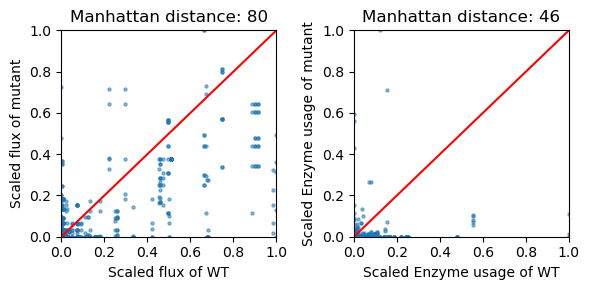

In [29]:
def min_max_normalize(data, feature_range=(0, 1)):
    """
    Min-Max 归一化函数，支持一维和二维数据
    :param data: 输入数据 (list, numpy array, pandas Series, pandas DataFrame)
    :param feature_range: 目标范围 (min, max)，默认 (0,1)
    :return: 归一化后的 numpy array 或 DataFrame
    """
    a, b = feature_range
    
    # 转换输入
    if isinstance(data, pd.DataFrame):
        return data.apply(lambda col: _normalize_array(col.values, a, b), axis=0)
    elif isinstance(data, pd.Series):
        return pd.Series(_normalize_array(data.values, a, b), index=data.index)
    else:
        arr = np.array(data, dtype=float)
        if arr.ndim == 1:
            return _normalize_array(arr, a, b)
        elif arr.ndim == 2:
            return np.apply_along_axis(_normalize_array, 0, arr, a, b)
        else:
            raise ValueError("仅支持一维或二维数据")

def _normalize_array(arr, a, b):
    """对一维数组进行归一化"""
    min_val, max_val = np.min(arr), np.max(arr)
    if min_val == max_val:  # 避免除零
        return np.full_like(arr, (a+b)/2, dtype=float)
    return a + (arr - min_val) * (b - a) / (max_val - min_val)


df_flux_all_scaled=min_max_normalize(df_flux_all)
df_protein_all_scaled=min_max_normalize(df_protein_all)

# calculate the Manhattan distance
def manhattan_distance(x, y):
    x, y = np.array(x), np.array(y)
    return np.sum(np.abs(x - y))

flux_manhattan_distance=manhattan_distance(df_flux_all_scaled['WT'],df_flux_all_scaled['mutant'])
protein_manhattan_distance=manhattan_distance(df_protein_all_scaled['WT'],df_protein_all_scaled['mutant'])
print(f'The Manhattan distance of flux is {flux_manhattan_distance}')
print(f'The Manhattan distance of protein is {protein_manhattan_distance}')

# plot scatter plot with y=x line
fig,ax=plt.subplots(1,2,figsize=(6,3))
ax[0].scatter(df_flux_all_scaled['WT'],df_flux_all_scaled['mutant'],s=5,alpha=0.5)
ax[0].plot([0,1],[0,1],color='red')
ax[0].set_xlabel('Scaled flux of WT')
ax[0].set_ylabel('Scaled flux of mutant')
ax[0].set_ylim(0,1)
ax[0].set_xlim(0,1)
ax[0].set_title(f'Manhattan distance: {flux_manhattan_distance:.0f}')

ax[1].scatter(df_protein_all_scaled['WT'],df_protein_all_scaled['mutant'],s=5,alpha=0.5)
ax[1].plot([0,1],[0,1],color='red')
ax[1].set_xlabel('Scaled Enzyme usage of WT')
ax[1].set_ylabel('Scaled Enzyme usage of mutant')
ax[1].set_ylim(0,1)
ax[1].set_xlim(0,1)
ax[1].set_title(f'Manhattan distance: {protein_manhattan_distance:.0f}')

plt.tight_layout()
plt.show()

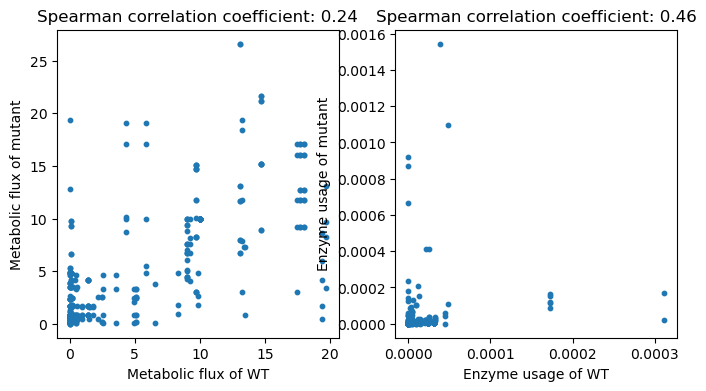

In [30]:
# plot scatter plot and add spearman corrlation coefficient
fig,ax=plt.subplots(1,2,figsize=(8,4))
# remove rows with all 0 value
df_flux_all=df_flux_all[df_flux_all.iloc[:,1:].sum(axis=1)!=0]
df_protein_all=df_protein_all[df_protein_all.iloc[:,1:].sum(axis=1)!=0]
# calculate spearman correlation coefficient
corr_flux,p_flux=stats.spearmanr(df_flux_all['WT'],df_flux_all['mutant'])
corr_protein,p_protein=stats.spearmanr(df_protein_all['WT'],df_protein_all['mutant'])

ax[0].scatter(df_flux_all['WT'],df_flux_all['mutant'],s=10)
ax[0].set_xlabel('Metabolic flux of WT')
ax[0].set_ylabel('Metabolic flux of mutant')
ax[0].set_title('Spearman correlation coefficient: {:.2f}'.format(corr))

ax[1].scatter(df_protein_all['WT'],df_protein_all['mutant'],s=10)
ax[1].set_xlabel('Enzyme usage of WT')
ax[1].set_ylabel('Enzyme usage of mutant')
ax[1].set_title('Spearman correlation coefficient: {:.2f}'.format(corr_protein))
plt.show()

The mean of protein logfc is 1.7226193068176743
The mean of flux logfc is 1.9802259208526332
The coefficient of variation of protein logfc is 0.833614684779269
The coefficient of variation of flux logfc is 1.0187693948373655


d:\softwares\programming\anoconda\envs\data\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


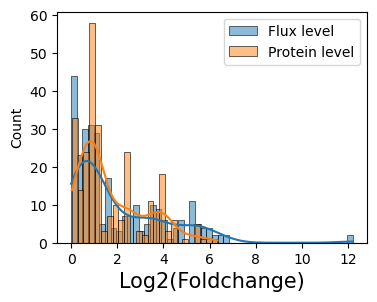

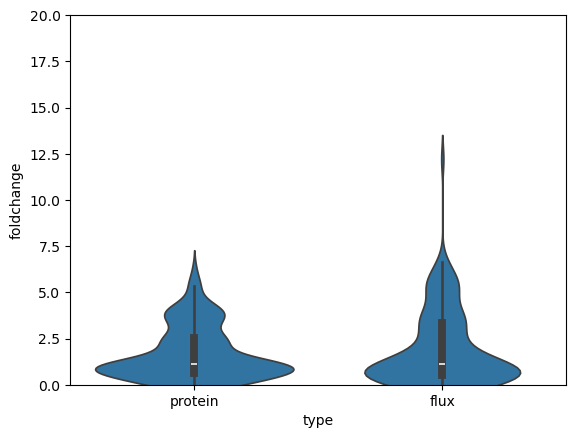

In [32]:
# plot the foldchange distribution
import seaborn as sns
import matplotlib.pyplot as plt

# only keep highly convident value 
df_protein_all[df_protein_all.apply(lambda row: row.all() > 10e-9, axis=1)]
df_flux_all[df_flux_all.apply(lambda row: row.all() > 10e-9, axis=1)]

# plot box plot
protein_foldchange=df_protein_all['WT']/df_protein_all['mutant']
flux_foldchange=df_flux_all['WT']/df_flux_all['mutant']

protein_logfc=np.abs(np.log2(protein_foldchange))
flux_logfc=np.abs(np.log2(flux_foldchange))

# # remove >50 and <1 
protein_logfc=protein_logfc[(protein_logfc<15) & (protein_logfc>0)]
flux_logfc=flux_logfc[(flux_logfc<15) & (flux_logfc>0)]

mean_protein=protein_logfc.mean()
mean_flux=flux_logfc.mean()
print(f'The mean of protein logfc is {mean_protein}')
print(f'The mean of flux logfc is {mean_flux}')

# calculate the coefficient of variation of protein foldchange and flux_foldchange
cv_protein=protein_logfc.std()/protein_logfc.mean()
cv_flux=flux_logfc.std()/flux_logfc.mean()
print(f'The coefficient of variation of protein logfc is {cv_protein}')
print(f'The coefficient of variation of flux logfc is {cv_flux}')

fig,ax=plt.subplots(figsize=(4,3))
# sns.kdeplot(flux_logfc,label='flux',fill=True)
# sns.kdeplot(flux_logfc,label='flux',fill=True)
sns.histplot(flux_logfc,kde=True,bins=50,label='Flux level',ax=ax)
sns.histplot(protein_logfc,kde=True,bins=25,label='Protein level',ax=ax)
# set x lim
ax.set_xlabel('Log2(Foldchange)',fontsize=15)
plt.legend()
plt.show()

# 构造DataFrame
df=pd.DataFrame({'foldchange':protein_logfc.values.tolist()+flux_logfc.values.tolist(),'type':['protein']*len(protein_logfc)+['flux']*len(flux_logfc)})
sns.violinplot(x="type", y="foldchange", data=df)
# set y lim
plt.ylim(0,20)
plt.show()

In [23]:
# only keep rows with all value > 10e-9
print('protein',len(protein_logfc[protein_logfc>5]))
print('flux',len(flux_logfc[flux_logfc>5]))

protein 8
flux 32


In [25]:
# save rsult
protein_flux_logfc_dict={'protein':protein_logfc.values.tolist(),'flux':flux_logfc.values.tolist()}
import json
with open(r'analysis_code\results\protein_flux_logfc_distribution.json','w') as f:
    json.dump(protein_flux_logfc_dict,f)


In [33]:
import pandas as pd
import os 
os.chdir(r'D:\code\github\strainOptimizer')
dfs = pd.read_excel(r'analysis_code\results\wt_vs_mutant_protein_flux.xlsx', sheet_name=None, index_col=0)

df_flux_all=pd.DataFrame(columns=['WT','mutant','product'])
df_protein_all=pd.DataFrame(columns=['WT','mutant','product'])
# calculate protein allocation difference by spearman correlation
products_result={}
for key,df in dfs.items():
    type=key.split('_')[0]
    product=key.split('_')[1]
    df['product']=product

    if type=='protein':
        df_protein_all=pd.concat([df_protein_all,df],axis=0,ignore_index=True)
    elif type=='flux':
        df_flux_all=pd.concat([df_flux_all,df],axis=0,ignore_index=True)

C:\Users\wangh\AppData\Local\Temp\ipykernel_39304\1012139708.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_protein_all=pd.concat([df_protein_all,df],axis=0,ignore_index=True)
C:\Users\wangh\AppData\Local\Temp\ipykernel_39304\1012139708.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_flux_all=pd.concat([df_flux_all,df],axis=0,ignore_index=True)


d:\softwares\programming\anoconda\envs\data\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


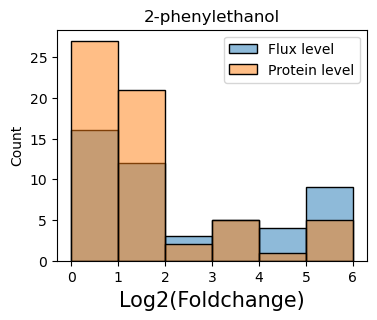

d:\softwares\programming\anoconda\envs\data\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


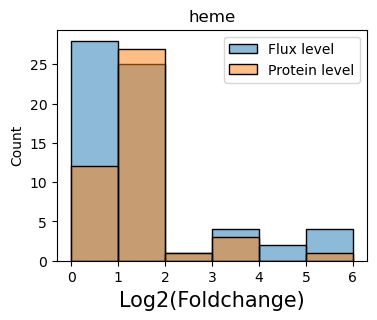

d:\softwares\programming\anoconda\envs\data\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


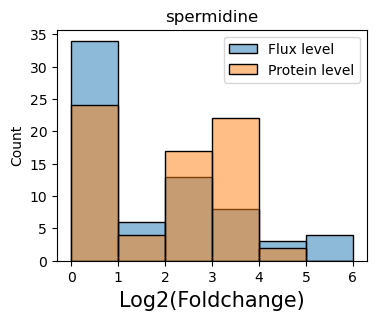

d:\softwares\programming\anoconda\envs\data\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


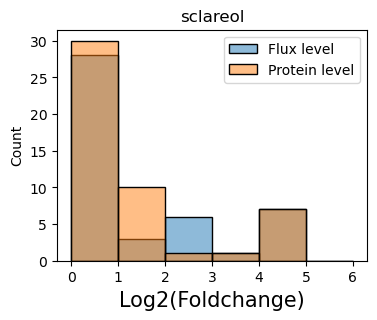

d:\softwares\programming\anoconda\envs\data\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


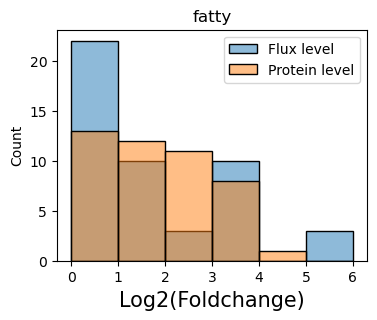

In [45]:
# plot for each product the distribution of foldchange
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# only keep highly convident value 
# df_protein_all[df_protein_all.apply(lambda row: row.all() > 10e-9, axis=1)]
# df_flux_all[df_flux_all.apply(lambda row: row.all() > 10e-9, axis=1)]
products_protein_flux_logfc_dict={}
for product in df_protein_all['product'].unique():
    df_protein_product=df_protein_all[df_protein_all['product']==product]
    df_flux_product=df_flux_all[df_flux_all['product']==product]
    # plot box plot
    protein_foldchange=df_protein_product['mutant']/df_protein_product['WT']
    flux_foldchange=df_flux_product['mutant']/df_flux_product['WT']

    protein_logfc=np.abs(np.log2(protein_foldchange))
    flux_logfc=np.abs(np.log2(flux_foldchange))

    # # remove >50 and <1 
    protein_logfc=protein_logfc[(protein_logfc<15) & (protein_logfc>0)]
    flux_logfc=flux_logfc[(flux_logfc<15) & (flux_logfc>0)]

    products_protein_flux_logfc_dict[product]={'protein':protein_logfc.values.tolist(),'flux':flux_logfc.values.tolist()}

    fig,ax=plt.subplots(figsize=(4,3))
    sns.histplot(flux_logfc,label='Flux level',ax=ax,bins=6,binrange=(0,6),alpha=0.5)
    sns.histplot(protein_logfc,label='Protein level',bins=6,binrange=(0,6),alpha=0.5)
    # set x lim
    ax.set_xlabel('Log2(Foldchange)',fontsize=15)
    plt.title(product)
    plt.legend()
    plt.show()

In [46]:
# save result
import json
with open(r'analysis_code\results\protein_flux_logfc_distribution_by_products.json','w') as f:
    json.dump(products_protein_flux_logfc_dict,f)